In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pandas.core.interchange.dataframe_protocol import DataFrame
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
import time
import seaborn as sns

In [2]:
MLF = pd.read_csv('EEG.machinelearing_data_BRMH.csv')

In [3]:
disorderset = set(MLF['specific.disorder'].values)

In [4]:
disorderset

{'Acute stress disorder',
 'Adjustment disorder',
 'Alcohol use disorder',
 'Behavioral addiction disorder',
 'Bipolar disorder',
 'Depressive disorder',
 'Healthy control',
 'Obsessive compulsitve disorder',
 'Panic disorder',
 'Posttraumatic stress disorder',
 'Schizophrenia',
 'Social anxiety disorder'}

In [5]:
disorderset = set(MLF['main.disorder'].values)

In [6]:
disorderset

{'Addictive disorder',
 'Anxiety disorder',
 'Healthy control',
 'Mood disorder',
 'Obsessive compulsive disorder',
 'Schizophrenia',
 'Trauma and stress related disorder'}

In [7]:
df = pd.DataFrame(MLF)

In [8]:
df.tail()

,no.,sex,age,eeg.date,education,IQ,main.disorder,specific.disorder,AB.A.delta.a.FP1,AB.A.delta.b.FP2,...,COH.F.gamma.o.Pz.p.P4,COH.F.gamma.o.Pz.q.T6,COH.F.gamma.o.Pz.r.O1,COH.F.gamma.o.Pz.s.O2,COH.F.gamma.p.P4.q.T6,COH.F.gamma.p.P4.r.O1,COH.F.gamma.p.P4.s.O2,COH.F.gamma.q.T6.r.O1,COH.F.gamma.q.T6.s.O2,COH.F.gamma.r.O1.s.O2
940,941,M,22.0,2014.8.28,13.0,116.0,Healthy control,Healthy control,41.851823,36.771496,...,82.905657,34.850706,63.970519,63.982003,51.244725,62.203684,62.062237,31.013031,31.183413,98.325230
941,942,M,26.0,2014.9.19,13.0,118.0,Healthy control,Healthy control,18.986856,19.401387,...,65.917918,66.700117,44.756285,49.787513,98.905995,54.021304,93.902401,52.740396,92.807331,56.320868
942,943,M,26.0,2014.9.27,16.0,113.0,Healthy control,Healthy control,28.781317,32.369230,...,61.040959,27.632209,45.552852,33.638817,46.690983,19.382928,41.050717,7.045821,41.962451,19.092111
943,944,M,24.0,2014.9.20,13.0,107.0,Healthy control,Healthy control,19.929100,25.196375,...,99.113664,48.328934,41.248470,28.192238,48.665743,42.007147,28.735945,27.176500,27.529522,20.028446
944,945,M,21.0,2015.10.23,13.0,105.0,Healthy control,Healthy control,65.195346,69.241972,...,78.600293,68.255430,70.687410,74.433908,74.294750,53.254681,72.755265,47.810386,80.166825,64.380273


In [9]:
# Checking for missing values

missing_values_count = df.isnull().sum()
missing_values_count

no.                       0
sex                       0
age                       0
eeg.date                  0
education                15
                         ..
COH.F.gamma.p.P4.r.O1     0
COH.F.gamma.p.P4.s.O2     0
COH.F.gamma.q.T6.r.O1     0
COH.F.gamma.q.T6.s.O2     0
COH.F.gamma.r.O1.s.O2     0
Length: 1149, dtype: int64

In [10]:
# Missing some education data (Not Important for my Study) and IQ data (May be important?)
# I will drop both for now

In [11]:
df.dropna(subset=['education', 'IQ'], inplace=True)

In [12]:
# https://www.kaggle.com/datasets/shashwatwork/eeg-psychiatric-disorders-dataset

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from nltk import ConfusionMatrix
from pandas.core.interchange.dataframe_protocol import DataFrame
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
import time
import seaborn as sns

In [14]:
# This data contains brain activity recorded from 1,142 different individuals.
# Wave activity was recorded by each patient while resting with eyes closed for several minutes.

MLF = pd.read_csv('EEG.machinelearing_data_BRMH.csv')

In [15]:
main_disorders = set(MLF['main.disorder'].values)

In [16]:
df = pd.DataFrame(MLF)
df.dropna(subset=['education', 'IQ'], inplace=True)

In [17]:
non_features = ['no.', 'sex', 'age', 'eeg.date', 'education', 'IQ',
                'main.disorder', 'specific.disorder', 'Unnamed: 122']

X = df.drop(columns=non_features)

# Targeting only main disorders
y = df['main.disorder']

In [18]:
# Starting off with KNN

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=42, stratify=y)

In [19]:
print("Training Set Size:", X_train.shape[0])
print("Testing Set Size:", X_test.shape[0])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Training Set Size: 643
Testing Set Size: 276


In [20]:
test_scores = []
k_range = range(1, 100)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)

    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5)

    test_scores.append(scores.mean())

# Once I find the best K I wil run it with the test set
best_k = k_range[test_scores.index(max(test_scores))]
print(f"Best K: {best_k}")

best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train_scaled, y_train)
final_score = best_knn.score(X_test_scaled, y_test)
print(f"Final test accuracy: {final_score}")

Best K: 69
Final test accuracy: 0.3007246376811594


In [21]:
# Using PCA to try to improve accuracy

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=50, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
explained_variance = pca.explained_variance_ratio_.sum()
print(f"Variance explained with 100 components: {explained_variance:.2%}")
X_test_pca = pca.transform(X_test_scaled)

# After your PCA transformation
test_scores_pca = []
k_range = range(1, 100)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_pca, y_train, cv=5)  # ← Using PCA data!
    test_scores_pca.append(scores.mean())

# Find best k for PCA
best_k_pca = k_range[test_scores_pca.index(max(test_scores_pca))]
print(f"Best k for PCA data: {best_k_pca}")

# Now train with the best k for PCA
best_knn = KNeighborsClassifier(n_neighbors=best_k_pca)
best_knn.fit(X_train_pca, y_train)
final_score = best_knn.score(X_test_pca, y_test)
print(f"Final test accuracy: {final_score}")

Variance explained with 100 components: 90.21%
Best k for PCA data: 63
Final test accuracy: 0.31521739130434784


In [22]:
data = np.array([10, 20, 30, 40, 50])
labels = np.array(['A', 'B', 'A', 'C', 'A'])

print("Filtered data:", data[labels == 'A'])

Filtered data: [10 30 50]


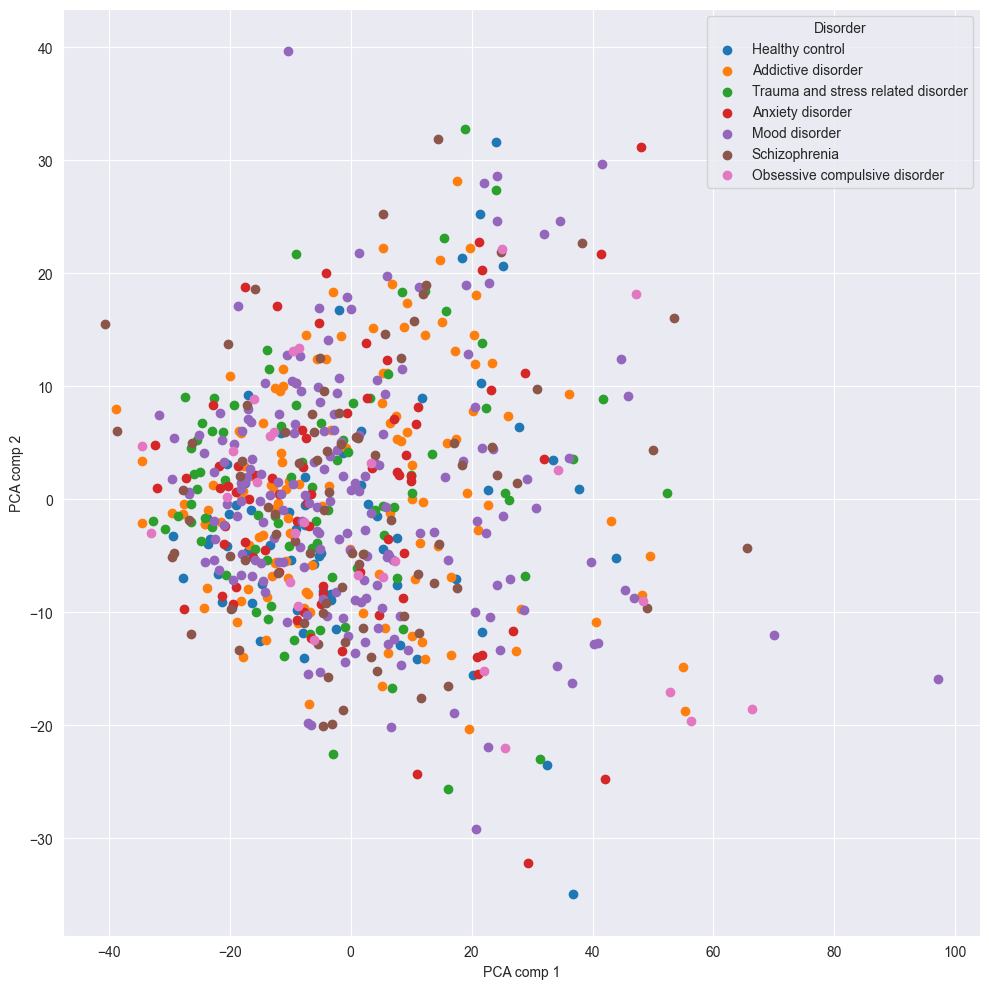

In [23]:
pca_scaled = PCA(n_components=2)
pca_scaled.fit(X_train_scaled)
scaled_pca_data = pca_scaled.transform(X_train_scaled)

plt.figure(figsize=(10,10))
for disorder in main_disorders:
    disorder_check = scaled_pca_data[y_train == disorder] # Correctly label each point (https://numpy.org/doc/stable/user/basics.indexing.html#boolean-array-indexing)
    plt.scatter(disorder_check[:,0], disorder_check[:,1], label=disorder)
plt.xlabel("PCA comp 1")
plt.ylabel("PCA comp 2")
plt.legend(title="Disorder",loc='best')
plt.tight_layout()
plt.show()

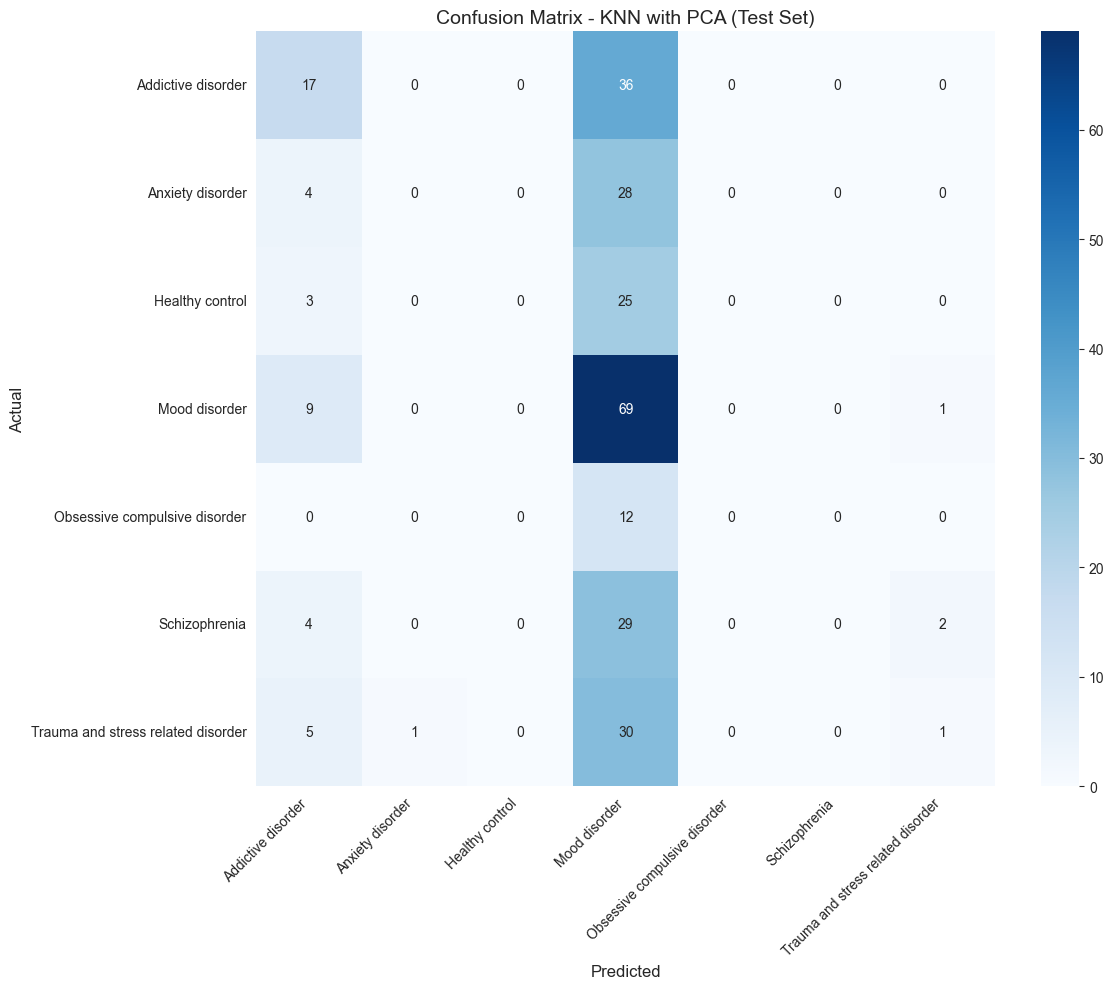

In [24]:
disorder_labels = sorted(y_test.unique())

cf = confusion_matrix(y_test, best_knn.predict(X_test_pca))

plt.figure(figsize=(12, 10))
sns.heatmap(cf, annot=True, fmt="d",
            xticklabels=disorder_labels, yticklabels=disorder_labels, cmap="Blues")
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - KNN with PCA (Test Set)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [25]:
# Not very good, I want at least 50% accuracy if not more
# I will try RF

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=42, stratify=y)

scores = []

rf = RandomForestClassifier(n_estimators=5000, max_depth=None, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
rf_cv_scores = cross_val_score(rf, X_train, y_train, cv=5)

print("Accuracy ",rf_cv_scores.mean())



Accuracy  0.32033672480620157


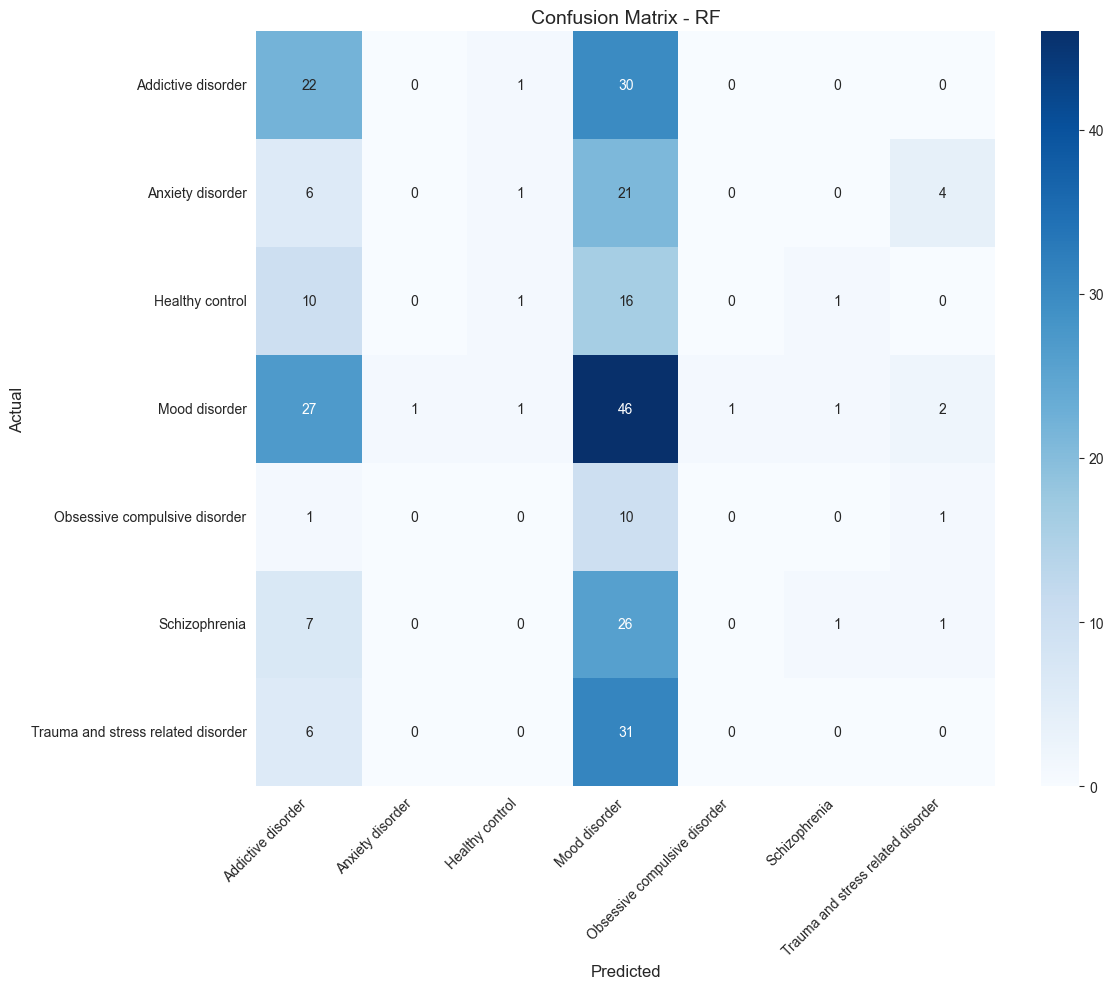

In [26]:
cf = confusion_matrix(y_test, rf.predict(X_test))

plt.figure(figsize=(12, 10))
sns.heatmap(cf, annot=True, fmt="d",
            xticklabels=disorder_labels, yticklabels=disorder_labels, cmap="Blues")
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - RF', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [27]:
# RF was about the same, I want to try binary tests, healthy vs specific main disorders
main_disorders

{'Addictive disorder',
 'Anxiety disorder',
 'Healthy control',
 'Mood disorder',
 'Obsessive compulsive disorder',
 'Schizophrenia',
 'Trauma and stress related disorder'}

In [28]:
df.insert(6,'binary.disorder',0)


In [29]:
df['binary.disorder'] = 0

df.loc[df['main.disorder'] == 'Anxiety disorder', 'binary.disorder'] = 1
df.loc[df['main.disorder'] == 'Healthy control', 'binary.disorder'] = 2

print(df['binary.disorder'].value_counts())
df

binary.disorder
0    720
1    106
2     93
Name: count, dtype: int64


,no.,sex,age,eeg.date,education,IQ,binary.disorder,main.disorder,specific.disorder,AB.A.delta.a.FP1,...,COH.F.gamma.o.Pz.p.P4,COH.F.gamma.o.Pz.q.T6,COH.F.gamma.o.Pz.r.O1,COH.F.gamma.o.Pz.s.O2,COH.F.gamma.p.P4.q.T6,COH.F.gamma.p.P4.r.O1,COH.F.gamma.p.P4.s.O2,COH.F.gamma.q.T6.r.O1,COH.F.gamma.q.T6.s.O2,COH.F.gamma.r.O1.s.O2
1,2,M,37.0,2012.9.6,6.0,120.0,0,Addictive disorder,Alcohol use disorder,13.425118,...,45.595619,17.510824,26.777368,28.201062,57.108861,32.375401,60.351749,13.900981,57.831848,43.463261
2,3,M,32.0,2012.9.10,16.0,113.0,0,Addictive disorder,Alcohol use disorder,29.941780,...,99.475453,70.654171,39.131547,69.920996,71.063644,38.534505,69.908764,27.180532,64.803155,31.485799
3,4,M,35.0,2012.10.8,18.0,126.0,0,Addictive disorder,Alcohol use disorder,21.496226,...,59.986561,63.822201,36.478254,47.117006,84.658376,24.724096,50.299349,35.319695,79.822944,41.141873
4,5,M,36.0,2012.10.18,16.0,112.0,0,Addictive disorder,Alcohol use disorder,37.775667,...,61.462720,59.166097,51.465531,58.635415,80.685608,62.138436,75.888749,61.003944,87.455509,70.531662
5,6,F,24.0,2012.11.21,14.0,105.0,0,Addictive disorder,Alcohol use disorder,13.482096,...,92.841723,82.302355,83.938567,88.213886,90.972026,77.443894,89.545596,72.579530,89.462863,86.127823
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
940,941,M,22.0,2014.8.28,13.0,116.0,2,Healthy control,Healthy control,41.851823,...,82.905657,34.850706,63.970519,63.982003,51.244725,62.203684,62.062237,31.013031,31.183413,98.325230
941,942,M,26.0,2014.9.19,13.0,118.0,2,Healthy control,Healthy control,18.986856,...,65.917918,66.700117,44.756285,49.787513,98.905995,54.021304,93.902401,52.740396,92.807331,56.320868
942,943,M,26.0,2014.9.27,16.0,113.0,2,Healthy control,Healthy control,28.781317,...,61.040959,27.632209,45.552852,33.638817,46.690983,19.382928,41.050717,7.045821,41.962451,19.092111
943,944,M,24.0,2014.9.20,13.0,107.0,2,Healthy control,Healthy control,19.929100,...,99.113664,48.328934,41.248470,28.192238,48.665743,42.007147,28.735945,27.176500,27.529522,20.028446


In [30]:
non_features = ['no.', 'sex', 'age', 'eeg.date', 'education', 'IQ',
                'main.disorder', 'specific.disorder', 'Unnamed: 122']

anxiety_healthy = df[df['binary.disorder'].isin([1, 2])]

X = anxiety_healthy.drop(columns=non_features)
y = anxiety_healthy['binary.disorder']

In [31]:
# Starting off with KNN
subset = df[df['binary.disorder'].isin([1, 2])]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=42, stratify=y)

In [32]:
print("Training Set Size:", X_train.shape[0])
print("Testing Set Size:", X_test.shape[0])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Training Set Size: 139
Testing Set Size: 60


In [33]:
test_scores = []
k_range = range(1, 100)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)

    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5)

    test_scores.append(scores.mean())

# Once I find the best K I wil run it with the test set
best_k = k_range[test_scores.index(max(test_scores))]
print(f"Best K: {best_k}")

best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train_scaled, y_train)
final_score = best_knn.score(X_test_scaled, y_test)
print(f"Final test accuracy: {final_score}")
# Still not good, coin toss

Best K: 3
Final test accuracy: 0.55


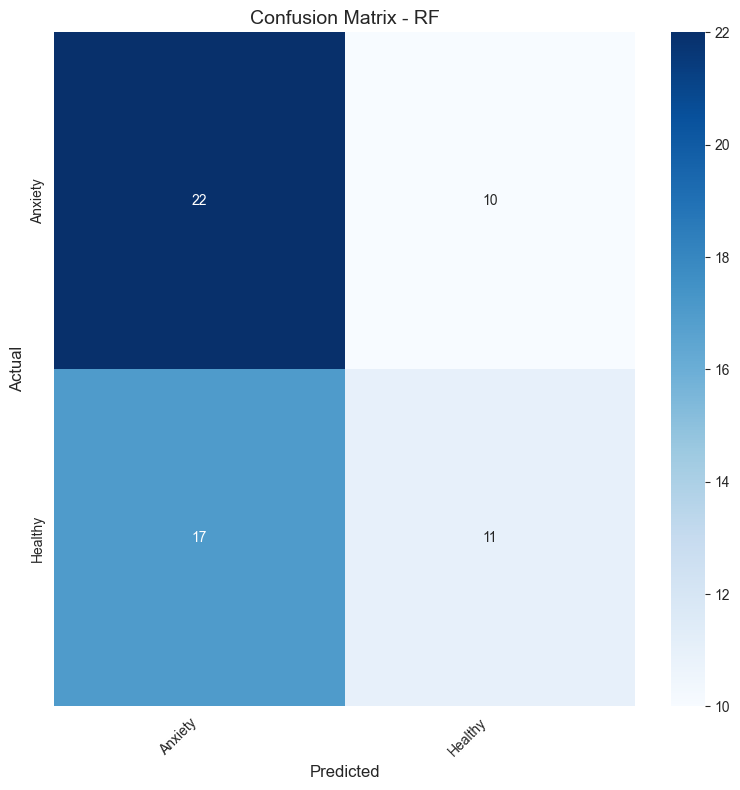

In [34]:
cf = confusion_matrix(y_test, best_knn.predict(X_test_scaled))

plt.figure(figsize=(8, 8))
sns.heatmap(cf, annot=True, fmt="d",
            xticklabels=["Anxiety", "Healthy"], yticklabels=["Anxiety", "Healthy"], cmap="Blues")
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - RF', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=42, stratify=y)

scores = []

rf = RandomForestClassifier(n_estimators=500, max_depth=9, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
rf_cv_scores = cross_val_score(rf, X_train, y_train, cv=5)

print("Accuracy ",rf_cv_scores.mean())

Accuracy  0.8124338624338623


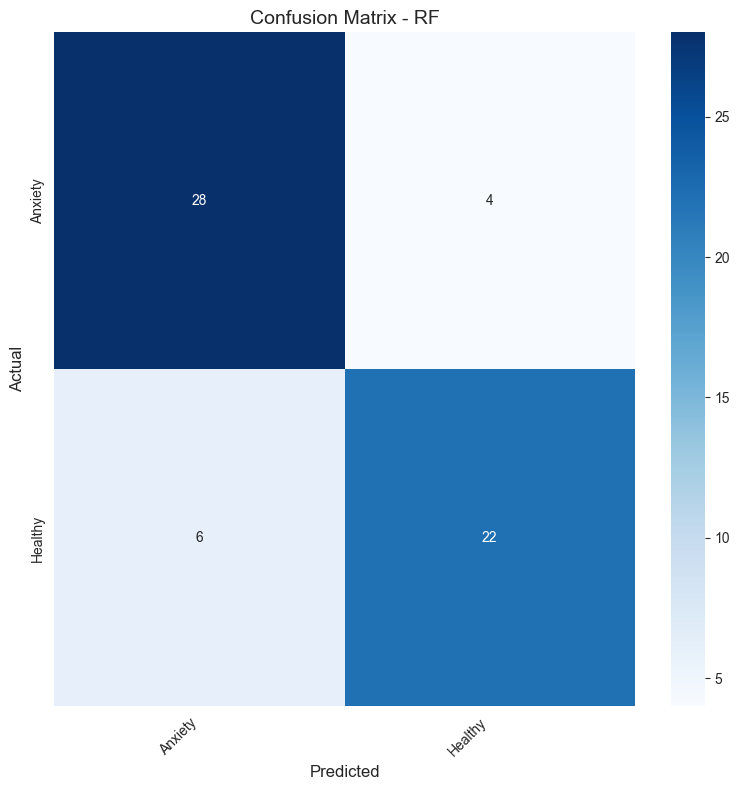

In [36]:
cf = confusion_matrix(y_test, rf.predict(X_test))

plt.figure(figsize=(8, 8))
sns.heatmap(cf, annot=True, fmt="d",
            xticklabels=["Anxiety", "Healthy"], yticklabels=["Anxiety", "Healthy"], cmap="Blues")
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - RF', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [37]:
df

,no.,sex,age,eeg.date,education,IQ,binary.disorder,main.disorder,specific.disorder,AB.A.delta.a.FP1,...,COH.F.gamma.o.Pz.p.P4,COH.F.gamma.o.Pz.q.T6,COH.F.gamma.o.Pz.r.O1,COH.F.gamma.o.Pz.s.O2,COH.F.gamma.p.P4.q.T6,COH.F.gamma.p.P4.r.O1,COH.F.gamma.p.P4.s.O2,COH.F.gamma.q.T6.r.O1,COH.F.gamma.q.T6.s.O2,COH.F.gamma.r.O1.s.O2
1,2,M,37.0,2012.9.6,6.0,120.0,0,Addictive disorder,Alcohol use disorder,13.425118,...,45.595619,17.510824,26.777368,28.201062,57.108861,32.375401,60.351749,13.900981,57.831848,43.463261
2,3,M,32.0,2012.9.10,16.0,113.0,0,Addictive disorder,Alcohol use disorder,29.941780,...,99.475453,70.654171,39.131547,69.920996,71.063644,38.534505,69.908764,27.180532,64.803155,31.485799
3,4,M,35.0,2012.10.8,18.0,126.0,0,Addictive disorder,Alcohol use disorder,21.496226,...,59.986561,63.822201,36.478254,47.117006,84.658376,24.724096,50.299349,35.319695,79.822944,41.141873
4,5,M,36.0,2012.10.18,16.0,112.0,0,Addictive disorder,Alcohol use disorder,37.775667,...,61.462720,59.166097,51.465531,58.635415,80.685608,62.138436,75.888749,61.003944,87.455509,70.531662
5,6,F,24.0,2012.11.21,14.0,105.0,0,Addictive disorder,Alcohol use disorder,13.482096,...,92.841723,82.302355,83.938567,88.213886,90.972026,77.443894,89.545596,72.579530,89.462863,86.127823
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
940,941,M,22.0,2014.8.28,13.0,116.0,2,Healthy control,Healthy control,41.851823,...,82.905657,34.850706,63.970519,63.982003,51.244725,62.203684,62.062237,31.013031,31.183413,98.325230
941,942,M,26.0,2014.9.19,13.0,118.0,2,Healthy control,Healthy control,18.986856,...,65.917918,66.700117,44.756285,49.787513,98.905995,54.021304,93.902401,52.740396,92.807331,56.320868
942,943,M,26.0,2014.9.27,16.0,113.0,2,Healthy control,Healthy control,28.781317,...,61.040959,27.632209,45.552852,33.638817,46.690983,19.382928,41.050717,7.045821,41.962451,19.092111
943,944,M,24.0,2014.9.20,13.0,107.0,2,Healthy control,Healthy control,19.929100,...,99.113664,48.328934,41.248470,28.192238,48.665743,42.007147,28.735945,27.176500,27.529522,20.028446
